# Examine fields returned from MITgcm `DINO` model run

adapted from notebook provided by Matt

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xmitgcm
import xgcm
import xarray as xr
import cmocean as cm

def write_float32(fout,fld):
    with open(fout, 'wb') as f:
        np.array(fld, dtype=">f").tofile(f)

def write_float64(fout,fld):
    with open(fout, 'wb') as f:
        np.array(fld, dtype=">f8").tofile(f)

def read_float32(fileIn):
    with open(fileIn, 'rb') as f:
        data = np.fromfile(f, dtype=np.dtype('>f'))
    return data

def read_float64(fileIn):
    with open(fileIn, 'rb') as f:
        data = np.fromfile(f, dtype=np.dtype('>f8'))
    return data


%load_ext autoreload
%autoreload 2

# Load diagnostics from the run
When tuning the model, I often change the length of the runtime and the diagnostic frequency set in `data.diagnostics`. When starting a new experiment, I've found that I need to delete the diag files in the run directory, rerun the model, and then restart the jupyter kernel in order for this notebook session to pick up on the fact that the diagnostic files have changed. 

In [2]:
run_dir = '/scratch2/tshahriar/DINO_MITgcm_v011526_frd_runs/DINO_MITgcm_v011526_frd_defaultd_run18153'

In [3]:
ds = xmitgcm.open_mdsdataset(
            run_dir,
            grid_dir=run_dir,
            prefix=['dynDiag'],
            geometry='curvilinear',
            delta_t=1800, 
            ref_date='2001-01-01T00:00:00'
)

In [4]:
ds

<xarray.Dataset>
Dimensions:   (i: 51, i_g: 51, j: 198, j_g: 198, k: 36, k_u: 36, k_l: 36,
               k_p1: 37, time: 598)
Coordinates: (12/44)
  * i         (i) int64 0 1 2 3 4 5 6 7 8 9 10 ... 41 42 43 44 45 46 47 48 49 50
  * i_g       (i_g) int64 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49 50
  * j         (j) int64 0 1 2 3 4 5 6 7 8 ... 190 191 192 193 194 195 196 197
  * j_g       (j_g) int64 0 1 2 3 4 5 6 7 8 ... 190 191 192 193 194 195 196 197
  * k         (k) int64 0 1 2 3 4 5 6 7 8 9 10 ... 26 27 28 29 30 31 32 33 34 35
  * k_u       (k_u) int64 0 1 2 3 4 5 6 7 8 9 ... 26 27 28 29 30 31 32 33 34 35
    ...        ...
    rhoRef    (k) >f4 dask.array<chunksize=(36,), meta=np.ndarray>
    dyF       (j, i) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dxV       (j_g, i_g) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dyU       (j_g, i_g) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    iter      (time) int64 dask.array<chunksize=(1,), meta=np.ndarray>
  * time      (time) datetime64[ns] 2001-01-31T12:00:00 ... 2050-12-09
Data variables:
    THETA     (time, k, j, i) float32 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    SALT      (time, k, j, i) float32 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    PHIHYD    (time, k, j, i) float32 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    RHOAnoma  (time, k, j, i) float32 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    UVEL      (time, k, j, i_g) float32 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    VVEL      (time, k, j_g, i) float32 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    WVEL      (time, k_l, j, i) float32 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    title:        netCDF wrapper of MITgcm MDS binary data
    source:       MITgcm
    history:      Created by calling `open_mdsdataset(grid_dir='/scratch2/tsh...

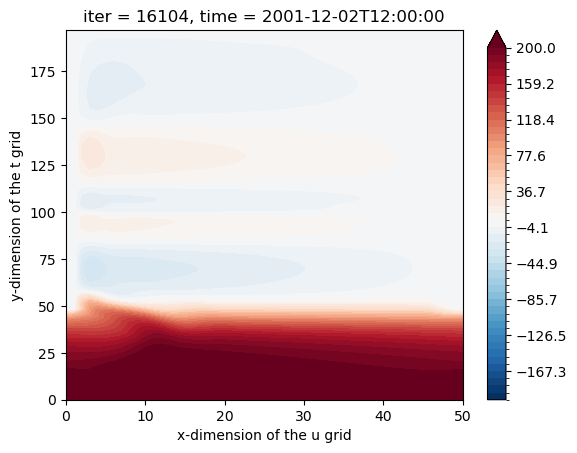

In [7]:
u_transport = (ds.UVEL * ds.hFacW * ds.dyG * ds.drF).sum('k')
psi = u_transport.sortby('j', ascending=False).cumsum('j') / 1e6 
psi = psi.sortby('j', ascending=True)
psi.isel(time=10).plot.contourf(levels=np.linspace(-200, 200, 50), vmin=-200, vmax=200, cmap='RdBu_r')

In [ ]:
root_dir = '/scratch/goldberg/dino_nw2/'
run_template_dir = root_dir + '/run_template_flip/'
run_dir = root_dir + 'run_flip/'

geometry='curvilinear'

diag_names = ['surf', 'dyn', 'atm', 'visc']
ds_list = []
for diag_name in diag_names:
    ds_list.append(
        xmitgcm.open_mdsdataset(run_dir, grid_dir=run_dir, prefix=[diag_name+'Diag'], geometry=geometry)
    )

ds = xr.merge(ds_list)

if 'time' in ds.dims:
    print(ds.sizes['time'])


# Compute barotropic streamfunction
First, let's look at the field we want to achieve. The author's of the DINO paper uploaded their barotropic streamfunction netcdf file (Figure 4 in the paper).

In [ ]:
psi_true = xr.open_dataset('/home/goldberg/dinostics/barotropic_streamfunction.nc')['barotropic_sf']

fig, ax = plt.subplots(figsize=(3, 7))
vmax = 200;vmin=-vmax;cmap=cm.cm.balance
levels=np.linspace(vmin, vmax, 49)
psi_true.plot.contourf(ax=ax, vmin=vmin, vmax=vmax, cmap=cmap, levels=levels)
psi_true.plot.contour(ax=ax, colors='k', linewidths=.4, levels=levels)

# Look at our barotropic streamfunction
Note that theirs was computed over many years of model spinup. While ours is at the very beginning of the spinup and not totally comparable, it is clear that our model will not achieve their state as it is currently constructed. 

In [ ]:
import xgcm
grid = xgcm.Grid(ds)
psi = grid.cumsum(-(ds.UVEL * ds.hFacW * ds.dyG * ds.drF).sum('k'), 'Y', boundary='fill')/1e6
psi_c = grid.interp(psi, ('X', 'Y'))
psi_c = psi_c.assign_coords(
    XC = ds.XC,
    YC = ds.YC
)

In [ ]:
vmax = 200

vmin = -vmax
levels = np.linspace(vmin, vmax, 50)
cmap = cm.cm.balance
pk = dict(vmin=vmin, vmax=vmax, cmap=cmap, levels=levels, extend='both')

fig, ax = plt.subplots(figsize=(5, 10))

psi_avg = psi_c.where(ds.hFacC[0])
#psi_avg = psi_avg[:-12]
psi_avg = psi_avg.mean('time')
psi_avg.plot.contourf(ax=ax, x='XC', y='YC', **pk)
psi_avg.plot.contour(x='XC', y='YC', linewidths=.5, colors='k', levels=levels)
hfc = ds.hFacC[-3]
hfc.where(hfc).plot.contour(x='XC', y='YC',colors='limegreen', add_colorbar=False)

# One major issue I'm seeing that could be causing the improper circulation:
We set the initial temperature and by the model's second timestep, it has rapidly moved away from this state. This I believe will later induces huge unphysical pressure gradients and in turn unphysical velocities that prevent us from reaching the steady state achieved in the paper.

In [ ]:
# Load initial temperature
fname = 'dino_T0.bin'
fpath = run_dir + fname
nz, nx, ny = ds.hFacC.shape
T0 = xmitgcm.utils.read_raw_data(fpath, np.dtype('>f8'), (nz, nx, ny))

# plot SST
fig, ax = plt.subplots()
nlev = 21
vmin=0;vmax=25
levels = np.linspace(vmin, vmax, nlev)
p = ax.contourf(T0[0], vmin=vmin, vmax=vmax, cmap=cm.cm.thermal, levels=levels, extend='both')
fig.colorbar(p, ax=ax)
ax.set_title('input T0')

The SST output by the model at timestep 1 (below, left) looks like the one we input (above). However, after just one timestep, the SST field has dramatically changed (below, right).

In [ ]:
ds.THETA.isel(k=0)[:2].plot(col='time', x='XC', y='YC', vmin=vmin, vmax=vmax, cmap=cm.cm.thermal, levels=levels, extend='both')

# Other stuff you can do:
Open up a forcing file! Here we compare the wind we feed in to the model ("offline") to the wind that the model registers and spits out ("online") just to make sure we've properly oriented the data.

In [ ]:
# load zonal wind stress used to force the model
fname = 'dino_utau.bin'
fpath = run_dir + fname
nz, nx, ny = ds.hFacC.shape
utau_offline = xmitgcm.utils.read_raw_data(fpath, np.dtype('>f8'), (365, nx, ny))

# wind forcing is constant in time in this simulation
 # there are 365 records in utau that are all identical
utau_offline = utau_offline[0]

# add to dataset just for convenients plotting
ds['utau_offline'] = xr.DataArray(utau_offline, dims=['j', 'i',])

# model returned the diagnostic ds.oceTAUX, which is the zonal wind stress
utau_online = grid.interp(ds.oceTAUX, 'X').assign_coords(XC=ds.XC, YC=ds.YC)
utau_online = utau_online.isel(time=1) # once again, all tau records are identical in time

# plot both
fig, ax = plt.subplots(figsize=(2, 5))
utau_online[:,0].T.plot(ax=ax, y='YC', linewidth=5, alpha=.5, c='k', label='online')
ds.utau_offline[:,0].T.plot(ax=ax, y='YC', c='r', label='offline')
ax.set_title('Zonal wind stress')
ax.set_xlim([-.125, .25])
ax.set_ylabel('Latitude')
ax.set_xlabel(r'$\tau_u$ $[Nm^{-2}]$')

ax.legend()
ax.grid()

This confirms the model is reading in the zonal wind stress forcing we are applying. Compare this with Figure 2 subplot 1 from the paper!